# DINOv3 crop linear probe

使用 `data/dataset/metadata.csv` 与已存盘 crop 图像快速验证：DINOv3 冻结特征 + 线性分类头在 train/val/test 三分割上的可靠性。

特点：
- 直接读取 stage 14 生成的 `data/dataset/images/*`，不再从原图 bbox 在线裁剪。
- 复用 pipeline 配置中的 DINOv3 模型名、batch size、学习率、weight decay，并复用 stage 10 的 `LinearHead`。
- 学习率保持固定，不使用 cyclic/sawtooth scheduler。
- 用 validation loss 早停，最后在 test split 上评估。

In [1]:
from pathlib import Path
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoImageProcessor, AutoModel
from huggingface_hub import login

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for path in candidates:
        if (path / "pyproject.toml").exists() and (path / "pipeline").exists():
            return path
    raise RuntimeError(f"Cannot find wakareeru project root from {start}")


PROJECT_ROOT = find_project_root()
for path in [PROJECT_ROOT, PROJECT_ROOT / "pipeline"]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import utils
from stage_09_DINOv3_feature_extraction import get_torch_device, FeatureCollator
from stage_10_train_loss_tracking import LinearHead

tqdm.pandas()

config = utils.load_pipeline_config(PROJECT_ROOT / "config" / "pipeline_config.yaml")
data_root = utils.get_data_root(config)
dataset_root = utils.join_data_root(config["path"]["dataset_dir"], config=config)
metadata_path = dataset_root / "metadata.csv"
labels_path = dataset_root / "labels.csv"

print(f"project_root={PROJECT_ROOT}")
print(f"dataset_root={dataset_root}")

project_root=/Users/yukun/projects/wakareeru
dataset_root=/Users/yukun/projects/wakareeru/data/dataset


In [2]:
# 实验参数。先保持小而直接，便于快速判断数据可靠性。
SEED = 42
LABEL_COLUMN = "label"
MIN_SAMPLES_PER_CLASS = 3
VAL_RATIO = 0.15
TEST_RATIO = 0.15

FEATURE_BATCH_SIZE = int(config["noise_detection"].get("feature_extraction_batch_size", 16))
HEAD_BATCH_SIZE = int(config["noise_detection"].get("linear_head_train_batch_size", 32))
# Notebook 中自定义 Dataset 定义在 __main__，macOS/Python 3.12 的 spawn 多进程
# 无法稳定 pickle；这里固定为 0，避免 DataLoader worker 导入失败。
NUM_WORKERS = 0

MAX_EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

LR = float(config["loss_noise_tracking"].get("learning_rate_high", 1e-3))
WEIGHT_DECAY = float(config["loss_noise_tracking"].get("weight_decay", 1e-4))
HF_MODEL_NAME = config["noise_detection"]["hf_model_name"]

feature_cache_dir = utils.join_data_root(
    config["noise_detection"].get("feature_cache_dir", "feature_cache"),
    config=config,
)
feature_cache_path = feature_cache_dir / "dataset_crop_dinov3_features.pt"

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(HF_MODEL_NAME, FEATURE_BATCH_SIZE, HEAD_BATCH_SIZE, LR, WEIGHT_DECAY)

facebook/dinov3-vits16-pretrain-lvd1689m 16 32 0.001 0.0001


In [3]:
# 先看当前 dataset 的 label 分布，确认类别数量和长尾情况。
metadata_preview = pd.read_csv(metadata_path)
metadata_preview[LABEL_COLUMN] = metadata_preview[LABEL_COLUMN].astype(str)

label_counts = metadata_preview[LABEL_COLUMN].value_counts().rename_axis(LABEL_COLUMN).reset_index(name="count")
num_labels = len(label_counts)
num_samples = len(metadata_preview)
num_too_small = int((label_counts["count"] < MIN_SAMPLES_PER_CLASS).sum())

print(f"samples={num_samples}, labels={num_labels}, labels_below_min_samples={num_too_small}")
display(label_counts)


samples=13341, labels=133, labels_below_min_samples=4


,label,count
0,103系,904
1,115系,804
2,D51形,786
3,205系,692
4,キハ58系,483
...,...,...
128,EF500形,3
129,ED77形,2
130,DB500形,2
131,DD19形,2


## 读取 metadata 并做三分割

`MIN_SAMPLES_PER_CLASS=3` 是为了让每个类别至少能落入 train/val/test。样本太少的类先过滤掉，否则 stratified split 本身不可靠。

In [4]:
metadata = pd.read_csv(metadata_path)
metadata["abs_image_path"] = metadata["image_path"].map(lambda p: dataset_root / str(p))
metadata["crop_id"] = metadata["image_path"].str.extract(r"_(\d+)\.").astype(int)
metadata[LABEL_COLUMN] = metadata[LABEL_COLUMN].astype(str)

exists_mask = metadata["abs_image_path"].progress_map(Path.exists)
if not exists_mask.all():
    print(f"missing image files: {(~exists_mask).sum()}")
metadata = metadata.loc[exists_mask].copy().reset_index(drop=True)

class_counts = metadata[LABEL_COLUMN].value_counts()
kept_labels = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
df = metadata[metadata[LABEL_COLUMN].isin(kept_labels)].copy().reset_index(drop=True)

labels = sorted(df[LABEL_COLUMN].unique())
label_to_id = {label: idx for idx, label in enumerate(labels)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
df["label_id_exp"] = df[LABEL_COLUMN].map(label_to_id).astype(int)

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=df["label_id_exp"],
)
relative_val_ratio = VAL_RATIO / (1.0 - TEST_RATIO)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_ratio,
    random_state=SEED,
    stratify=train_val_df["label_id_exp"],
)

split_frames = {
    "train": train_df.reset_index(drop=True),
    "val": val_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}
for split, part in tqdm(split_frames.items(), desc="split summary"):
    print(split, part.shape, "classes=", part[LABEL_COLUMN].nunique())

display(df[LABEL_COLUMN].value_counts().rename("count").to_frame().head(30))

  0%|          | 0/13341 [00:00<?, ?it/s]

split summary:   0%|          | 0/3 [00:00<?, ?it/s]

train (9333, 17) classes= 129
val (2000, 17) classes= 128
test (2001, 17) classes= 125


,count
label,
103系,904
115系,804
D51形,786
205系,692
キハ58系,483
201系,451
E3系,441
EF65形,417
DE10形,395


## DINOv3 特征抽取

如果 `feature_cache_path` 已存在，默认直接加载；想重抽特征时把 `REBUILD_FEATURE_CACHE=True`。

In [5]:
class StoredCropDataset(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["abs_image_path"]).convert("RGB")
        meta = {
            "crop_id": int(row["crop_id"]),
            "label": str(row[LABEL_COLUMN]),
            "split": row["split"],
        }
        return image, meta


def extract_features(frame: pd.DataFrame, processor, model, label_to_id: dict[str, int], batch_size: int):
    dataset = StoredCropDataset(frame)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=FeatureCollator(processor, label_to_id),
    )
    features, labels_out, crop_ids = [], [], []
    model.eval()
    with torch.inference_mode():
        for image_tensors, labels_cpu, crop_ids_cpu in tqdm(loader, desc="DINOv3 features"):
            image_tensors = image_tensors.to(model.device)
            outputs = model(image_tensors)
            features.append(outputs.pooler_output.detach().cpu())
            labels_out.append(labels_cpu.cpu())
            crop_ids.append(crop_ids_cpu.cpu())
    return {
        "features": torch.cat(features, dim=0),
        "labels": torch.cat(labels_out, dim=0),
        "crop_ids": torch.cat(crop_ids, dim=0),
    }

In [6]:
REBUILD_FEATURE_CACHE = False

split_df = pd.concat(
    [part.assign(split=split) for split, part in split_frames.items()],
    ignore_index=True,
)

if feature_cache_path.exists() and not REBUILD_FEATURE_CACHE:
    feature_cache = torch.load(feature_cache_path, map_location="cpu")
    print(f"loaded feature cache: {feature_cache_path}")
else:
    token = os.getenv("HF_TOKEN")
    if token:
        login(token=token)
    device = get_torch_device()
    processor = AutoImageProcessor.from_pretrained(HF_MODEL_NAME)
    model = AutoModel.from_pretrained(HF_MODEL_NAME, device_map="auto")
    feature_parts = []
    for split in tqdm(["train", "val", "test"], desc="feature splits"):
        part = split_df[split_df["split"] == split].reset_index(drop=True)
        extracted = extract_features(part, processor, model, label_to_id, FEATURE_BATCH_SIZE)
        extracted["splits"] = [split] * len(part)
        feature_parts.append(extracted)
    feature_cache = {
        "features": torch.cat([p["features"] for p in feature_parts], dim=0),
        "labels": torch.cat([p["labels"] for p in feature_parts], dim=0),
        "crop_ids": torch.cat([p["crop_ids"] for p in feature_parts], dim=0),
        "splits": sum([p["splits"] for p in feature_parts], []),
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "model_name": HF_MODEL_NAME,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    feature_cache_dir.mkdir(parents=True, exist_ok=True)
    torch.save(feature_cache, feature_cache_path)
    print(f"saved feature cache: {feature_cache_path}")

print(feature_cache["features"].shape, len(feature_cache["label_to_id"]))

loaded feature cache: /Users/yukun/projects/wakareeru/data/feature_cache/dataset_crop_dinov3_features.pt
torch.Size([13334, 384]) 129


## 固定学习率训练线性头 + 早停

In [7]:
class FeatureSplitDataset(torch.utils.data.Dataset):
    def __init__(self, feature_cache: dict, split: str):
        split_mask = np.array(feature_cache["splits"]) == split
        self.features = feature_cache["features"][split_mask].float()
        self.labels = feature_cache["labels"][split_mask].long()
        self.crop_ids = feature_cache["crop_ids"][split_mask].long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.crop_ids[idx]


def evaluate_head(head, loader, criterion, device, desc="evaluate"):
    head.eval()
    losses, preds, labels, crop_ids, confidences = [], [], [], [], []
    with torch.inference_mode():
        for x_cpu, y_cpu, crop_ids_cpu in tqdm(loader, desc=desc, leave=False):
            x = x_cpu.to(device)
            y = y_cpu.to(device)
            logits = head(x)
            per_sample_loss = torch.nn.functional.cross_entropy(logits, y, reduction="none")
            prob = torch.softmax(logits, dim=1)
            confidence, pred = prob.max(dim=1)
            losses.append(per_sample_loss.detach().cpu())
            preds.append(pred.detach().cpu())
            labels.append(y_cpu.cpu())
            crop_ids.append(crop_ids_cpu.cpu())
            confidences.append(confidence.detach().cpu())
    sample_losses = torch.cat(losses).numpy()
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    crop_ids = torch.cat(crop_ids).numpy()
    confidences = torch.cat(confidences).numpy()
    return {
        "loss": float(sample_losses.mean()),
        "accuracy": float(accuracy_score(labels, preds)),
        "sample_loss": sample_losses,
        "confidence": confidences,
        "preds": preds,
        "labels": labels,
        "crop_ids": crop_ids,
    }


train_ds = FeatureSplitDataset(feature_cache, "train")
val_ds = FeatureSplitDataset(feature_cache, "val")
test_ds = FeatureSplitDataset(feature_cache, "test")

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=HEAD_BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
head = LinearHead(
    input_dim=int(feature_cache["features"].shape[1]),
    num_classes=len(feature_cache["label_to_id"]),
).to(device)
optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = torch.nn.CrossEntropyLoss()

best_val_loss = float("inf")
best_state = None
bad_epochs = 0
history = []

for epoch in tqdm(range(MAX_EPOCHS), desc="linear head"):
    head.train()
    running_loss = 0.0
    running_correct = 0
    running_n = 0
    for x_cpu, y_cpu, _ in tqdm(train_loader, desc=f"epoch {epoch} train", leave=False):
        x = x_cpu.to(device)
        y = y_cpu.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = head(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.detach().cpu()) * int(y.numel())
        running_correct += int(logits.argmax(dim=1).eq(y).sum().detach().cpu())
        running_n += int(y.numel())

    train_loss = running_loss / max(1, running_n)
    train_acc = running_correct / max(1, running_n)
    val_metrics = evaluate_head(head, val_loader, criterion, device, desc=f"epoch {epoch} val")
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)
    print(row)

    if val_metrics["loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_metrics["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"early stopping at epoch={epoch}, best_val_loss={best_val_loss:.4f}")
            break

history_df = pd.DataFrame(history)
if best_state is not None:
    head.load_state_dict(best_state)
display(history_df.tail())


linear head:   0%|          | 0/100 [00:00<?, ?it/s]

epoch 0 train:   0%|          | 0/292 [00:00<?, ?it/s]

epoch 0 val:   0%|          | 0/63 [00:00<?, ?it/s]

{'epoch': 0, 'train_loss': 2.7686361869559417, 'train_accuracy': 0.4119789992499732, 'val_loss': 2.0030202865600586, 'val_accuracy': 0.5765, 'lr': 0.001}


epoch 1 train:   0%|          | 0/292 [00:00<?, ?it/s]

...

{'epoch': 27, 'train_loss': 0.3449838667849336, 'train_accuracy': 0.9135326261652202, 'val_loss': 0.9167740345001221, 'val_accuracy': 0.7805, 'lr': 0.001}


epoch 28 train:   0%|          | 0/292 [00:00<?, ?it/s]

epoch 28 val:   0%|          | 0/63 [00:00<?, ?it/s]

{'epoch': 28, 'train_loss': 0.3378704899276783, 'train_accuracy': 0.9138540662166506, 'val_loss': 0.9204530119895935, 'val_accuracy': 0.7805, 'lr': 0.001}
early stopping at epoch=28, best_val_loss=0.9051


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,lr
24,24,0.373280,0.906675,0.909457,0.7835,0.001
25,25,0.362411,0.910104,0.920712,0.7805,0.001
26,26,0.354552,0.911068,0.915393,0.7825,0.001
27,27,0.344984,0.913533,0.916774,0.7805,0.001
28,28,0.337870,0.913854,0.920453,0.7805,0.001


## Validation diagnostics and test summary

先用 validation split 看类别被吸走到哪里；test split 保留整体泛化指标。

In [8]:
val_metrics = evaluate_head(head, val_loader, criterion, device, desc="val diagnostics")
test_metrics = evaluate_head(head, test_loader, criterion, device, desc="test")
print("val", {k: v for k, v in val_metrics.items() if k in ["loss", "accuracy"]})
print("test", {k: v for k, v in test_metrics.items() if k in ["loss", "accuracy"]})

target_names = [feature_cache["id_to_label"][i] for i in range(len(feature_cache["id_to_label"]))]
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
))


val diagnostics:   0%|          | 0/63 [00:00<?, ?it/s]

test:   0%|          | 0/63 [00:00<?, ?it/s]

val {'loss': 0.9050970673561096, 'accuracy': 0.7855}
test {'loss': 0.8995392322540283, 'accuracy': 0.776111944027986}
              precision    recall  f1-score   support

        101系       0.71      0.36      0.48        14
        103系       0.78      0.83      0.81       136
        105系       0.70      0.77      0.73        43
        107系       1.00      0.86      0.92         7
        115系       0.78      0.92      0.84       121
        123系       0.83      0.83      0.83         6
        143系       0.75      0.50      0.60         6
        145系       0.25      0.33      0.29         3
        157系       0.80      0.80      0.80         5
        165系       0.68      0.56      0.61        27
        167系       0.67      0.50      0.57         4
        169系       0.67      0.57      0.62         7
        183系       0.67      0.43      0.52        14
        185系       0.85      0.81      0.83        27
        189系       0.56      0.74      0.64        19
        193系     

In [9]:
DIAGNOSTIC_OUTPUT_DIR = dataset_root / "diagnostics"
DIAGNOSTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def build_prediction_frame(metrics: dict, split_name: str) -> pd.DataFrame:
    result = pd.DataFrame({
        "sample_id": metrics["crop_ids"],
        "crop_id": metrics["crop_ids"],
        "label_id": metrics["labels"],
        "pred_id": metrics["preds"],
        "confidence": metrics["confidence"],
        "loss": metrics["sample_loss"],
    })
    result["true_label"] = result["label_id"].map(feature_cache["id_to_label"])
    result["pred_label"] = result["pred_id"].map(feature_cache["id_to_label"])
    result["correct"] = result["label_id"] == result["pred_id"]
    result["split"] = split_name

    meta_cols = ["crop_id", "image_path", LABEL_COLUMN, "series", "fine_grained_series", "submodel"]
    meta_cols = [col for col in meta_cols if col in split_df.columns]
    split_meta = split_df[split_df["split"] == split_name][meta_cols].copy()
    return result.merge(split_meta, on="crop_id", how="left")


val_result_df = build_prediction_frame(val_metrics, "val")
test_result_df = build_prediction_frame(test_metrics, "test")

train_counts = train_df[LABEL_COLUMN].value_counts().rename("train_count")
val_counts = val_df[LABEL_COLUMN].value_counts().rename("val_count")
report_dict = classification_report(
    val_metrics["labels"],
    val_metrics["preds"],
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
    output_dict=True,
)
per_class_metrics = pd.DataFrame(report_dict).T.loc[target_names, ["precision", "recall", "f1-score"]]
per_class_metrics = per_class_metrics.rename(columns={"f1-score": "f1"})
class_diagnostics = (
    pd.concat([train_counts, val_counts, per_class_metrics], axis=1)
    .fillna({"train_count": 0, "val_count": 0})
    .rename_axis("class")
    .reset_index()
)
class_diagnostics[["train_count", "val_count"]] = class_diagnostics[["train_count", "val_count"]].astype(int)
class_diagnostics = class_diagnostics.sort_values(["val_count", "recall", "class"], ascending=[True, True, True])
absorbed_small_classes = class_diagnostics.query("val_count < 20 and recall < 0.6 and precision > recall").copy()

cm = confusion_matrix(
    val_metrics["labels"],
    val_metrics["preds"],
    labels=list(range(len(target_names))),
)
confused_rows = []
for true_id, true_label in enumerate(target_names):
    true_total = int(cm[true_id].sum())
    if true_total == 0:
        continue
    for pred_id, pred_label in enumerate(target_names):
        if true_id == pred_id:
            continue
        count = int(cm[true_id, pred_id])
        if count == 0:
            continue
        confused_rows.append({
            "true_label": true_label,
            "pred_label": pred_label,
            "count": count,
            "percentage_of_true_class": 100.0 * count / true_total,
        })
if confused_rows:
    top_confused_pairs = (
        pd.DataFrame(confused_rows)
        .sort_values(["count", "percentage_of_true_class", "true_label", "pred_label"], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )
else:
    top_confused_pairs = pd.DataFrame(columns=["true_label", "pred_label", "count", "percentage_of_true_class"])

high_conf_wrong_samples = (
    val_result_df.loc[~val_result_df["correct"] & (val_result_df["confidence"] > 0.8),
                      ["sample_id", "image_path", "true_label", "pred_label", "confidence", "loss"]]
    .sort_values(["confidence", "loss"], ascending=[False, False])
    .reset_index(drop=True)
)

class_diagnostics.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_class_diagnostics.csv", index=False)
absorbed_small_classes.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_absorbed_small_classes.csv", index=False)
top_confused_pairs.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_top_confused_pairs.csv", index=False)
high_conf_wrong_samples.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_high_confidence_wrong_samples.csv", index=False)

print(f"diagnostics saved to: {DIAGNOSTIC_OUTPUT_DIR}")
print("Table 1: per-class train/val support and validation metrics")
display(class_diagnostics)
print("Filtered: val_count < 20, recall < 0.6, precision > recall")
display(absorbed_small_classes)
print("Table 2: validation top confused pairs")
display(top_confused_pairs.head(50))
print("Table 3: validation high-confidence wrong samples")
display(high_conf_wrong_samples.head(100))


diagnostics saved to: /Users/yukun/projects/wakareeru/data/dataset/diagnostics
Table 1: per-class train/val support and validation metrics


,class,train_count,val_count,precision,recall,f1
122,FV-E991系,3,0,0.000000,0.000000,0.000000
113,193系,6,1,0.000000,0.000000,0.000000
107,207系,7,1,0.000000,0.000000,0.000000
119,301系,4,1,0.000000,0.000000,0.000000
120,401系,3,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
4,キハ58系,338,73,0.773810,0.890411,0.828025
3,205系,484,104,0.762712,0.865385,0.810811
2,D51形,550,118,0.824427,0.915254,0.867470
1,115系,562,121,0.798450,0.851240,0.824000


Filtered: val_count < 20, recall < 0.6, precision > recall


,class,train_count,val_count,precision,recall,f1
105,952/953形,9,2,1.000000,0.500000,0.666667
108,E954形,7,2,1.000000,0.500000,0.666667
99,EF55形,11,2,1.000000,0.500000,0.666667
83,145系,16,3,1.000000,0.333333,0.500000
87,DE11形,15,3,1.000000,0.333333,0.500000
92,GV-E197系,13,3,1.000000,0.333333,0.500000
90,キハ37形,13,3,0.500000,0.333333,0.400000
74,ED79形,21,4,0.500000,0.250000,0.333333
82,M250系,16,4,1.000000,0.500000,0.666667
73,キハE120形,21,4,0.666667,0.500000,0.571429


Table 2: validation top confused pairs


,true_label,pred_label,count,percentage_of_true_class
0,C58形,D51形,12,37.500000
1,583系,489系,9,23.684211
2,E3系,E2系,7,10.606061
3,105系,103系,6,13.953488
4,E2系,E3系,6,13.043478
5,209系,205系,6,11.111111
6,201系,103系,6,8.823529
7,205系,209系,6,5.769231
8,D51形,C58形,6,5.084746
9,103系,105系,6,4.411765


Table 3: validation high-confidence wrong samples


,sample_id,image_path,true_label,pred_label,confidence,loss
0,10496,images/00024323_00010496.jpeg,209系,205系,0.994927,5.608401
1,5903,images/00019912_00005903.jpeg,E2系,E4系,0.992903,6.006497
2,7018,images/00020921_00007018.jpeg,D51形,DE10形,0.989687,7.407475
3,17329,images/00031097_00017329.jpeg,キハ58系,EF58形,0.989244,9.705713
4,19136,images/00032751_00019136.jpeg,EF200形,EF210形,0.988544,9.874597
...,...,...,...,...,...,...
75,17075,images/00030830_00017075.jpeg,143系,583系,0.806095,3.682084
76,13433,images/00027356_00013433.jpeg,189系,EF63形,0.803097,5.210269
77,16046,images/00029875_00016046.jpeg,103系,105系,0.802433,2.526442
78,8359,images/00022177_00008359.jpeg,DE10形,D51形,0.802313,4.448774


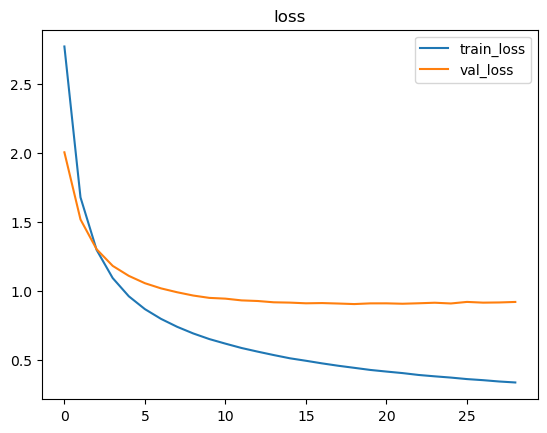

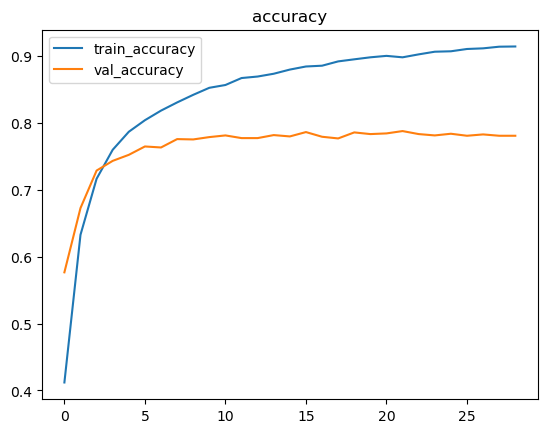

In [10]:
import matplotlib.pyplot as plt

history_df[["train_loss", "val_loss"]].plot(title="loss")
plt.show()
history_df[["train_accuracy", "val_accuracy"]].plot(title="accuracy")
plt.show()